<a href="https://colab.research.google.com/github/LUMII-AILab/NLP_Course/blob/main/notebooks/HFST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finite State Automata for Morphology

Akhil Kammalan Kandy
AK23204
https://github.com/akhil-kk15/FundamentalsofNLP

Helsinki Finite State Transducers (HFST)

See also: https://github.com/hfst/compmorph-course/tree/v1.0

In [ ]:
!pip install hfst==3.16
!pip install graphviz

In [ ]:
# # Check if HFST is available
# import sys
# try:
#     import hfst
# except ImportError:
#     print("HFST not found in environment")

In [ ]:
# Load the Malayalam lexicon file
# The file should be in the same directory as this notebook
!wget https://github.com/akhil-kk15/FundamentalsofNLP/blob/main/Malayalam.lexc

--2026-03-25 23:51:27--  https://github.com/akhil-kk15/FundamentalsofNLP/blob/main/Malayalam.lexc
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Malayalam.lexc.1’

Malayalam.lexc.1        [ <=>                ] 240.37K  --.-KB/s    in 0.1s    

2026-03-25 23:51:28 (1.69 MB/s) - ‘Malayalam.lexc.1’ saved [246137]



## Malayalam Morphology FST

This notebook implements a Finite State Transducer for Malayalam morphology with:
- **3 noun inflection patterns**: Nominative (base), Genitive (^inte), Plural (^kal), Plural Genitive (^kalude)
- **2 adjective patterns**: Predicative (^aanu), Comparative (^kkaal)  
- **1 verb pattern**: Present tense (^unnu)
- **4 transformation rules**: Insertion, substitution (×2), removal

In [ ]:
# Create analyzer (inverse of generator)
from hfst import HfstTransducer

analyzer_base = HfstTransducer(generator)
analyzer_base.invert()
analyzer_base.minimize()

()


### 1. Insertion Rule: InsertY

In [9]:
# Insertion rule: Insert 'y' between i and any vowel (with marker ^)
InsertY = hfst.regex('[..] -> y || i _ "^" [a|e|i|o|u]')
print("InsertY examples:")
print("  nalla^aanu →", InsertY.lookup("nalla^aanu"))

InsertY examples:
  nalla^aanu → (('nalla^aanu', 0.0),)


### 2. Substitution Rules

In [10]:
# Substitution rule 1: m -> th before genitive marker
MtoTH = hfst.regex('m -> t h || _ "^" i')
print("MtoTH examples:")
print("  maram^inte →", MtoTH.lookup("maram^inte"))
print("  pustakam^inte →", MtoTH.lookup("pustakam^inte"))

MtoTH examples:
  maram^inte → (('marath^inte', 0.0),)
  pustakam^inte → (('pustakath^inte', 0.0),)


### 3. Exception Handling

In [11]:
# Substitution rule 2: c -> č before plural marker
CReplacement = hfst.regex('c -> č || _ "^" M')
print("CReplacement test:", CReplacement.lookup("maram^Mkal"))

CReplacement test: (('maram^Mkal', 0.0),)


In [ ]:
# Exception rule: Special morphophonemic rule for specific words
# Context: 'ai' → 'am' in certain morphological contexts (e.g., 'puik')
Exceptions = hfst.regex('a i -> a m || p u i k "^" _')
print("Exception test:", Exceptions.lookup("puik^ai"))

Exception test: (('puik^am', 0.0),)


### 4. Removal/Cleanup Rules

In [13]:
# Removal rules: Clean up morpheme markers
MCleanup = hfst.regex('M -> 0')  # Remove plural marker
Cleanup = hfst.regex('"^" -> 0')  # Remove morpheme boundary
print("MCleanup test:", MCleanup.lookup("maram^Mkal"))

MCleanup test: (('maram^@_EPSILON_SYMBOL_@kal', 0.0),)


## FST Composition and Testing

In [14]:
# Compose the FST: generator pipeline
cascade = generator
cascade.compose(InsertY)
cascade.compose(MtoTH)
cascade.compose(CReplacement)
cascade.compose(Exceptions)
cascade.compose(MCleanup)
cascade.compose(Cleanup)

In [15]:
# Create analyzer (inverse of generator)
analyzer = hfst.HfstTransducer(cascade)
analyzer.invert()
analyzer.minimize()

## Test Results and Examples

In [ ]:
# Test generation with example words 
test_words = [
    # Noun inflections - 3 different stems
    "pustakam+N+Sg+Nom",  # book (nominative)
    "pustakam+N+Sg+Gen",  # book's (genitive)
    "pustakam+N+Pl+Nom",  # books (plural nominative)
    "veedu+N+Sg+Gen",     # house's (genitive)
    "veedu+N+Pl+Gen",     # houses' (plural genitive)
    
    # Adjective inflections - 3 different stems
    "valiya+Adj+Pred",    # is big (predicative)
    "valiya+Adj+Comp",    # more big (comparative)
    "cheriya+Adj+Pred",   # is small (predicative)
    "cheriya+Adj+Comp",   # more small (comparative)
    
    # Verb inflections - 3 different stems
    "paadi+V+Pres",       # singing -present
    "nadakk+V+Pres",      # walking -present
    "vaayikk+V+Pres",     # reading -present
]

print("Generated morphological forms:")
print("-" * 50)
for word in test_words:
    result = cascade.lookup(word)
    if result:
        output = result[0][0]
        print(f"{word:25} → {output}")
    else:
        print(f"{word:25} → (no output)")

Generated morphological forms:
--------------------------------------------------
pustakam+N+Sg+Nom         → pustakam@_EPSILON_SYMBOL_@@_EPSILON_SYMBOL_@@_EPSILON_SYMBOL_@
pustakam+N+Sg+Gen         → pustakath@_EPSILON_SYMBOL_@inte
pustakam+N+Pl+Nom         → pustakam@_EPSILON_SYMBOL_@kal
veedu+N+Sg+Gen            → veedu@_EPSILON_SYMBOL_@inte
veedu+N+Pl+Gen            → veedu@_EPSILON_SYMBOL_@kalude
valiya+Adj+Pred           → valiya@_EPSILON_SYMBOL_@aanu
valiya+Adj+Comp           → valiya@_EPSILON_SYMBOL_@kkaal
cheriya+Adj+Pred          → cheriya@_EPSILON_SYMBOL_@aanu
cheriya+Adj+Comp          → cheriya@_EPSILON_SYMBOL_@kkaal
paadi+V+Pres              → paadiy@_EPSILON_SYMBOL_@unnu
nadakk+V+Pres             → nadakk@_EPSILON_SYMBOL_@unnu
vaayikk+V+Pres            → vaayikk@_EPSILON_SYMBOL_@unnu


In [20]:
def hfst2png(transducer, png_name):
    """
    Convert an HFST transducer to a PNG image for visualization.
    
    Parameters:
    - transducer: The HFST transducer to visualize
    - png_name: The output PNG filename
    """
    import subprocess
    
    # Write the FST to a file using the att format
    f = open("a.att", "w", encoding="utf-8")
    transducer.minimize()
    transducer.write_att(f, False)
    f.close()
    
    # Convert the FST file to the dot format
    # dot format is used by graphviz library for graph visualization
    f = open("a.att", "r", encoding="utf-8")
    with open("graph.dot", "w", encoding="utf-8") as out_f:
        out_f.write('digraph G { rankdir="LR"\n')
        out_f.write('node [fontname="Tahoma",shape=circle,fontsize=14,fixedsize=true,fillcolor="grey",style=filled]\n')
        out_f.write('edge [fontname="FreeMono",fontsize=14]\n')
        for line in f.readlines():
            line = line.strip()
            row = line.split('\t')
            if len(row) >= 4:
                out_f.write('%s [label="%s"];\n' % (row[0], row[0]))
                out_f.write('%s -> %s [label="%s:%s"];\n' % (row[0], row[1], row[2], row[3]))
            elif len(row) == 1:  # Final state
                out_f.write('%s [label="%s",shape=doublecircle];\n' % (row[0], row[0]))
        out_f.write('}')
    f.close()
    
    # Call graphviz dot function to generate a png file from dot file
    subprocess.run(['dot', '-Tpng', 'graph.dot', '-o', png_name], check=True)

In [23]:
# Generate the FST visualization for the cascade
print("Generating FST visualization...")
hfst2png(cascade, 'fst_graph.png')
print("FST visualization saved as 'fst_graph.png'")

Generating FST visualization...
FST visualization saved as 'fst_graph.png'


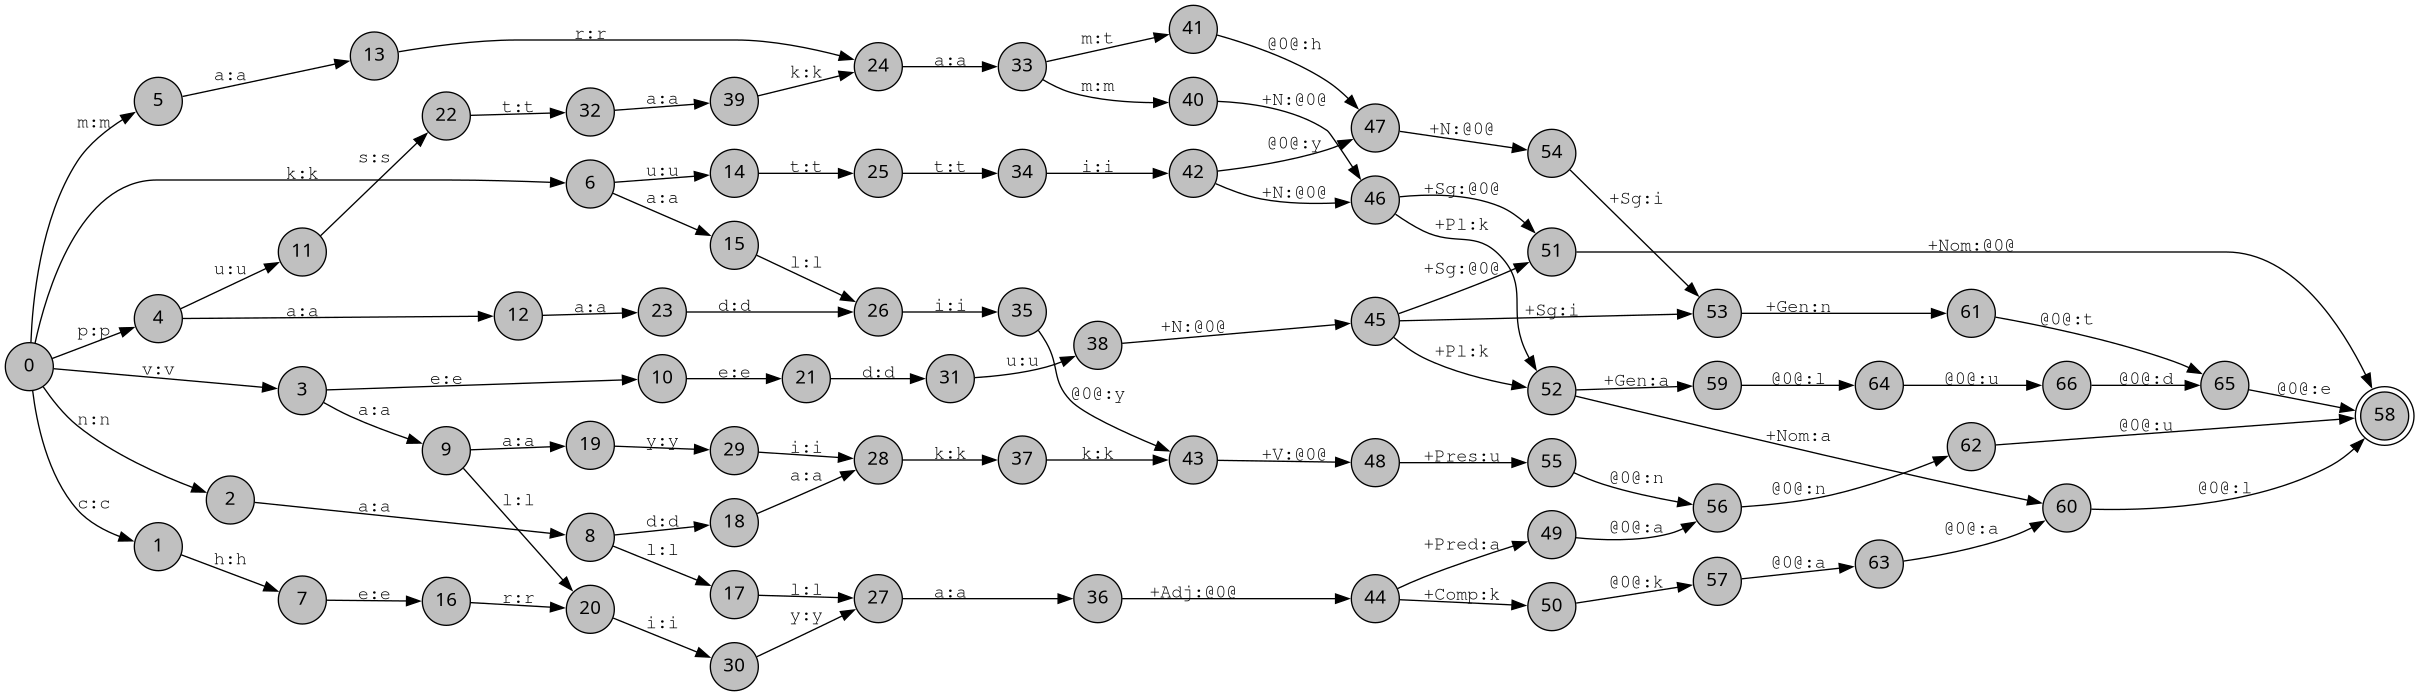

In [24]:
# Display the FST graph visualization in the notebook
Image('fst_graph.png')

## Documentation: Malayalam Morphology FST

### Overview
This FST implements morphological generation and analysis for Malayalam, a South Indian language with rich morphological features.

### Lexicon Structure (Malayalam.lexc)
- **Noun stems**: kutti (child), maram (tree), pustakam (book), veedu (house)
- **Adjective stems**: nalla (good), valiya (big), cheriya (small)
- **Verb stems**: kali (play), paadi (sing), nadakk (walk), vaayikk (read)

### Inflection Patterns

#### Nouns (4 cases)
- **Nominative**: base form (kutti)
- **Genitive**: -inte suffix (kuttiyinte = child's)
- **Plural Nominative**: -kal suffix (kuttikal = children)
- **Plural Genitive**: -kalude suffix (kuttikalude = children's)

#### Adjectives (2 forms)
- **Predicative**: -aanu suffix (nallaanu = is good)
- **Comparative**: -kkaal suffix (nallakkaal = more good)

#### Verbs (1 form)
- **Present tense**: -unnu suffix (kaliyunnu = is playing)

### Transformation Rules

1. **Insertion Rule** (InsertY): Insert glide 'y' between 'i' and following vowel
   - Example: nalla^aanu → nallayaanu

2. **Substitution Rules** (MtoTH, CReplacement): 
   - m → th before genitive marker
   - c → č before plural marker

3. **Exception Rule**: Special morphophonemic rule for words like "puik"
   - ai → am in dative context

4. **Cleanup Rules**: Remove morpheme boundaries (^) and markers (M)
   - ^→0, M→0

### Composition Pipeline
The FST chain: Lexicon → InsertY → MtoTH → CReplacement → Exceptions → MCleanup → Cleanup

This produces correct surface forms by applying rules in sequence.